In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import sys
import os
from einops import repeat, rearrange
import pathlib
# Get the directory containing this notebook (notebooks/)
notebook_dir = pathlib.Path().resolve()
# Go up two levels: notebooks -> crate_implementation -> intelligence_lab
project_root = notebook_dir.parent.parent
sys.path.insert(0, str(project_root))
print(f"Added to Python path: {project_root}")

from crate_implementation.models import CRATEClassification
from crate_implementation.utils import CodingRate, cal_sparsity, remove_all_hooks

# Check for available device (CUDA, MPS, or CPU)
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")


Added to Python path: /Users/kelng/Documents/GitHub
Using device: mps


# Load the data

In [3]:
# Load Fashion-MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))  # Fashion-MNIST mean and std
])

train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Create data loaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Batch size: {batch_size}")


Training samples: 60000
Test samples: 10000
Batch size: 64


# Initialize Model

In [4]:
# Initialize the model
model = CRATEClassification(
    img_size=28,
    patch_size=7,  # 7x7 patches -> 4x4 = 16 patches total
    in_channels=1,
    embed_dim=36,
    num_classes=10,
    num_blocks=8,
    num_heads=6,
    dim_head=6,  # 6 heads * 6 dim_head = 36 embed_dim
    dropout=0.1
).to(device)

# Print model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Test forward pass
sample_batch = next(iter(train_loader))[0][:4].to(device)
with torch.no_grad():
    output = model(sample_batch)
    print(f"\nSample input shape: {sample_batch.shape}")
    print(f"Sample output shape: {output.shape}")
    print(f"Sample predictions: {output.argmax(dim=1)}")


Total parameters: 35,434
Trainable parameters: 35,434

Sample input shape: torch.Size([4, 1, 28, 28])
Sample output shape: torch.Size([4, 10])
Sample predictions: tensor([3, 3, 3, 3], device='mps:0')


In [5]:
# Visualize Model Structure with TensorBoard
from crate_implementation.utils import visualize_model_graph

# Create a sample input for visualization (single image, normalized)
sample_input = torch.randn(1, 1, 28, 28).to(device)

# Visualize the model structure
writer = visualize_model_graph(
    model=model,
    sample_input=sample_input,
    log_dir="runs/model_visualization",
    model_name="crate_fashion_mnist",
    verbose=True
)

# Close the writer (optional, but good practice)
writer.close()


Visualizing model structure...
Model: CRATEClassification
Sample input shape: torch.Size([1, 1, 28, 28])
Log directory: /Users/kelng/Documents/GitHub/crate_implementation/notebooks/runs/model_visualization/crate_fashion_mnist

✓ Model graph successfully logged to TensorBoard!

To view the visualization, run:
  tensorboard --logdir=/Users/kelng/Documents/GitHub/crate_implementation/notebooks/runs/model_visualization

Then open your browser and navigate to: http://localhost:6006
Click on the 'GRAPHS' tab to view the model structure.


# Training

In [6]:
# Setup training
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-5)

# Training function
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })
    
    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


# Evaluation function
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        pbar = tqdm(loader, desc='Evaluating')
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100.*correct/total:.2f}%'
            })
    
    avg_loss = total_loss / len(loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy


In [ ]:
# Training loop
num_epochs = 10
train_losses = []
train_accs = []
test_losses = []
test_accs = []

# Create checkpoints directory
notebook_dir = pathlib.Path().resolve()
checkpoints_dir = notebook_dir / 'checkpoints'
checkpoints_dir.mkdir(exist_ok=True)

# Model configuration (needed to recreate the model)
model_config = {
    'img_size': 28,
    'patch_size': 7,
    'in_channels': 1,
    'embed_dim': 36,
    'num_classes': 10,
    'num_blocks': 8,
    'num_heads': 6,
    'dim_head': 6,
    'dropout': 0.1,
    'pool': 'cls'
}

print("Starting training...")
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 50)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Evaluate
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    # Update learning rate
    scheduler.step()
    
    # Save checkpoint after each epoch
    checkpoint_path = checkpoints_dir / f'checkpoint_epoch_{epoch+1}.pt'
    checkpoint = {
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'model_config': model_config,
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_loss': train_loss,
        'train_acc': train_acc,
        'test_loss': test_loss,
        'test_acc': test_acc,
        'learning_rate': scheduler.get_last_lr()[0]
    }
    torch.save(checkpoint, checkpoint_path)
    
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")
    print(f"Learning Rate: {scheduler.get_last_lr()[0]:.6f}")
    print(f"Checkpoint saved: {checkpoint_path}")


Starting training...

Epoch 1/10
--------------------------------------------------


Evaluating: 100%|██████████| 157/157 [00:04<00:00, 35.43it/s, loss=0.4766, acc=77.86%]



Epoch 1 Summary:
Train Loss: 0.8946, Train Acc: 67.50%
Test Loss: 0.5963, Test Acc: 77.86%
Learning Rate: 0.000976
Checkpoint saved: /Users/kelng/Documents/GitHub/crate_implementation/notebooks/checkpoints/checkpoint_epoch_1.pt

Epoch 2/10
--------------------------------------------------


Evaluating: 100%|██████████| 157/157 [00:03<00:00, 41.84it/s, loss=0.3591, acc=80.84%]



Epoch 2 Summary:
Train Loss: 0.5877, Train Acc: 78.70%
Test Loss: 0.5150, Test Acc: 80.84%
Learning Rate: 0.000905
Checkpoint saved: /Users/kelng/Documents/GitHub/crate_implementation/notebooks/checkpoints/checkpoint_epoch_2.pt

Epoch 3/10
--------------------------------------------------


...


Epoch 8 Summary:
Train Loss: 0.4084, Train Acc: 85.03%
Test Loss: 0.3998, Test Acc: 85.66%
Learning Rate: 0.000105
Checkpoint saved: /Users/kelng/Documents/GitHub/crate_implementation/notebooks/checkpoints/checkpoint_epoch_8.pt

Epoch 9/10
--------------------------------------------------


Evaluating: 100%|██████████| 157/157 [00:03<00:00, 41.23it/s, loss=0.2646, acc=85.80%]



Epoch 9 Summary:
Train Loss: 0.3990, Train Acc: 85.43%
Test Loss: 0.3938, Test Acc: 85.80%
Learning Rate: 0.000034
Checkpoint saved: /Users/kelng/Documents/GitHub/crate_implementation/notebooks/checkpoints/checkpoint_epoch_9.pt

Epoch 10/10
--------------------------------------------------


Evaluating: 100%|██████████| 157/157 [00:03<00:00, 40.50it/s, loss=0.2521, acc=86.11%]


Epoch 10 Summary:
Train Loss: 0.3910, Train Acc: 85.70%
Test Loss: 0.3848, Test Acc: 86.11%
Learning Rate: 0.000010
Checkpoint saved: /Users/kelng/Documents/GitHub/crate_implementation/notebooks/checkpoints/checkpoint_epoch_10.pt


# Save model

In [8]:
# Save the trained model
import pathlib

# Get the notebook directory
notebook_dir = pathlib.Path().resolve()

# Create checkpoints directory next to data directory
checkpoints_dir = notebook_dir / 'checkpoints'
checkpoints_dir.mkdir(exist_ok=True)

# Model configuration (needed to recreate the model)
model_config = {
    'img_size': 28,
    'patch_size': 7,
    'in_channels': 1,
    'embed_dim': 36,
    'num_classes': 10,
    'num_blocks': 8,
    'num_heads': 6,
    'dim_head': 6,
    'dropout': 0.1,
    'pool': 'cls'
}

# Training history
training_history = {
    'train_losses': train_losses,
    'train_accs': train_accs,
    'test_losses': test_losses,
    'test_accs': test_accs,
    'num_epochs': num_epochs,
    'best_train_acc': max(train_accs),
    'best_test_acc': max(test_accs)
}

# Save model state dict and configuration
model_path = checkpoints_dir / 'crate_fashion_mnist_model.pt'
checkpoint = {
    'model_state_dict': model.state_dict(),
    'model_config': model_config,
    'training_history': training_history,
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
}

torch.save(checkpoint, model_path)
print(f"Model saved to: {model_path}")
print(f"Model saved to absolute path: {model_path.resolve()}")
print(f"\nModel configuration:")
for key, value in model_config.items():
    print(f"  {key}: {value}")
print(f"\nTraining results:")
print(f"  Best train accuracy: {max(train_accs):.2f}%")
print(f"  Best test accuracy: {max(test_accs):.2f}%")

Model saved to: /Users/kelng/Documents/GitHub/crate_implementation/notebooks/checkpoints/crate_fashion_mnist_model.pt
Model saved to absolute path: /Users/kelng/Documents/GitHub/crate_implementation/notebooks/checkpoints/crate_fashion_mnist_model.pt

Model configuration:
  img_size: 28
  patch_size: 7
  in_channels: 1
  embed_dim: 36
  num_classes: 10
  num_blocks: 8
  num_heads: 6
  dim_head: 6
  dropout: 0.1
  pool: cls

Training results:
  Best train accuracy: 85.70%
  Best test accuracy: 86.11%


# Plot Losses

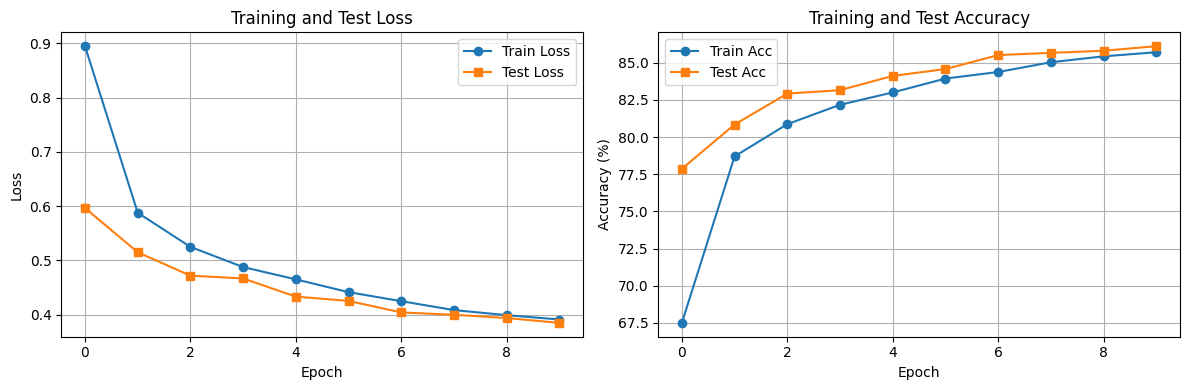


Final Results:
Best Train Accuracy: 85.70%
Best Test Accuracy: 86.11%


In [9]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
ax1.plot(train_losses, label='Train Loss', marker='o')
ax1.plot(test_losses, label='Test Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Test Loss')
ax1.legend()
ax1.grid(True)

# Accuracy plot
ax2.plot(train_accs, label='Train Acc', marker='o')
ax2.plot(test_accs, label='Test Acc', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Test Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"\nFinal Results:")
print(f"Best Train Accuracy: {max(train_accs):.2f}%")
print(f"Best Test Accuracy: {max(test_accs):.2f}%")


# Load model

In [ ]:
model_path = pathlib.Path('models/crate_fashion_mnist_model.pt')

if model_path.exists():
    print(f"Loading model from: {model_path}")
    checkpoint = torch.load(model_path, map_location=device)
    
    # Recreate model with saved configuration
    model_config = checkpoint['model_config']
    model = CRATEClassification(**model_config).to(device)
    
    # Load model weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    # Load training history if available
    if 'training_history' in checkpoint:
        training_history = checkpoint['training_history']
        train_losses = training_history['train_losses']
        train_accs = training_history['train_accs']
        test_losses = training_history['test_losses']
        test_accs = training_history['test_accs']
        num_epochs = training_history['num_epochs']
        
        print(f"\nLoaded training history:")
        print(f"  Epochs trained: {num_epochs}")
        print(f"  Best train accuracy: {training_history['best_train_acc']:.2f}%")
        print(f"  Best test accuracy: {training_history['best_test_acc']:.2f}%")
    
    print("\nModel loaded successfully!")
    print(f"Model configuration:")
    for key, value in model_config.items():
        print(f"  {key}: {value}")
else:
    print(f"Model file not found at: {model_path}")
    print("Please train the model first or check the path.")


# Hook

In [103]:
# Remove any existing hooks before registering new ones
remove_all_hooks(model)

coding_rate_list = []
sparsity_list = []
block_outputs_list = []
# List to store w values
w_list = []
coding_rate = CodingRate()

def forward_hook_codingrate(module, input, output):
    coding_rate_list.append(coding_rate(rearrange(output, 'b n (h d) -> b h n d', h=model.crate.blocks[0].mssa.heads)))

def forward_hook_sparsity(module, input, output):
    sparsity_list.append(cal_sparsity(output.cpu().numpy(), is_sparse=True))

def forward_hook_block_output(module, input, output):
    # Detach to avoid keeping gradients, move to CPU for visualization
    # Shape: [batch, seq_len, dim]
    block_outputs_list.append(output.detach().cpu())

def forward_hook_w(module, input, output):
    # Capture the w tensor (reshaped QKV output) from MSSA module
    # Shape: [batch, heads, seq_len, dim_head]
    w_list.append(output.detach().cpu())

# Store hook handles so they can be removed later if needed

for block in model.crate.blocks:
    block.mssa.qkv.register_forward_hook(forward_hook_codingrate)
    block.ista.register_forward_hook(forward_hook_sparsity)
    # Register hook on the encoder block itself to capture its output
    block.ista.register_forward_hook(forward_hook_block_output)
    # Register hook on MSSA module to capture w tensor (reshaped QKV output)
    block.mssa.qkv.register_forward_hook(forward_hook_w)

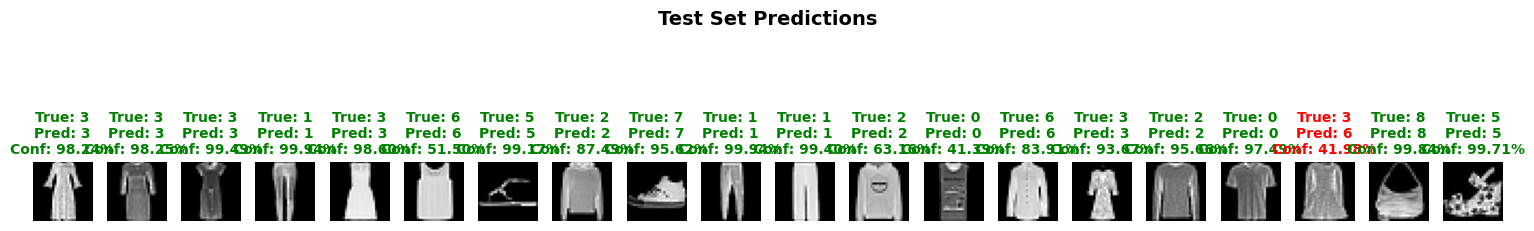


Prediction Summary:
Correct: 19/20
Accuracy: 95.0%


In [66]:
# Visualize 5 predictions from test set
model.eval()

# Get 5 random samples from test set
num_samples = 20
sample_indices = torch.randint(0, len(test_dataset), (num_samples,))
samples = [test_dataset[i] for i in sample_indices]

# Prepare batch
images = torch.stack([sample[0] for sample in samples]).to(device)
true_labels = torch.tensor([sample[1] for sample in samples]).to(device)

# Make predictions
with torch.no_grad():
    outputs = model(images)
    probabilities = F.softmax(outputs, dim=1)
    predicted_labels = outputs.argmax(dim=1)
    confidence_scores = probabilities.max(dim=1)[0]

# Denormalize images for visualization
# Fashion-MNIST normalization: mean=0.2860, std=0.3530
mean = torch.tensor([0.2860], device=images.device)
std = torch.tensor([0.3530], device=images.device)
images_denorm = images * std.view(1, 1, 1, 1) + mean.view(1, 1, 1, 1)
images_denorm = torch.clamp(images_denorm, 0, 1)

# Move data to cpu for visualization and comparison
images_denorm = images_denorm.cpu()
true_labels_cpu = true_labels.cpu()
predicted_labels_cpu = predicted_labels.cpu()
confidence_scores_cpu = confidence_scores.cpu()

# Create visualization
fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))

for i in range(num_samples):
    ax = axes[i]
    img = images_denorm[i].squeeze().numpy()
    true_label = true_labels_cpu[i].item()
    pred_label = predicted_labels_cpu[i].item()
    confidence = confidence_scores_cpu[i].item()
    
    # Display image
    ax.imshow(img, cmap='gray')
    ax.axis('off')
    
    # Color code: green if correct, red if incorrect
    color = 'green' if true_label == pred_label else 'red'
    
    # Add title with true label, prediction, and confidence
    title = f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2%}'
    ax.set_title(title, color=color, fontsize=10, fontweight='bold')

plt.suptitle('Test Set Predictions', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Print summary
print(f"\nPrediction Summary:")
correct = (predicted_labels_cpu == true_labels_cpu).sum().item()
print(f"Correct: {correct}/{num_samples}")
print(f"Accuracy: {100*correct/num_samples:.1f}%")


# Analysis

1. The $R^{c}\left(Z^{\ell+1/2}\mid U_{[K]}^{\ell}\right)$ of MSSA output and $\left\lVert Z^{\ell+1}\right\rVert_{0}$ of ISTA block output
2. Low-rankness of $Z$
3. Auto-correlation of subspaces in each layer $[U_1^{\ell},\ldots,U_K^{\ell}]^{*},[U_1^{\ell},\ldots,U_K^{\ell}] \in \mathbb{R}^{pK \times pK}$
4. Clustering [CLS] representation
5. Semantic meaning of each attention head
6. Self-attention map 
7. If there are $K$ classes for token representation, each class might be represented by a subset of columns in dictionary $D$. $U_[k]$ might be corresponding to a subset of column in $D$
8. Compare features of 1 and 7.

# Sample batch forward pass

In [104]:
# Select a batch of 10 images of class 9 from the test set
num_samples = 10
class_idx = 1

# Get indices of test dataset for class 9
indices_class9 = [i for i, (_, label) in enumerate(test_dataset) if label == class_idx][:num_samples]
images = torch.stack([test_dataset[i][0] for i in indices_class9]).to(device)

with torch.no_grad():
    outputs = model(images)

# Analysis

In [105]:
# Compute mean and standard deviation across all batches and heads
means = []
std_devs = []
for (mean, std) in coding_rate_list:
    means.append(mean.item())
    std_devs.append(std.item())

sparsities = []
std_sparsities = []
for (mean, std) in sparsity_list:
    sparsities.append(mean)
    std_sparsities.append(std)

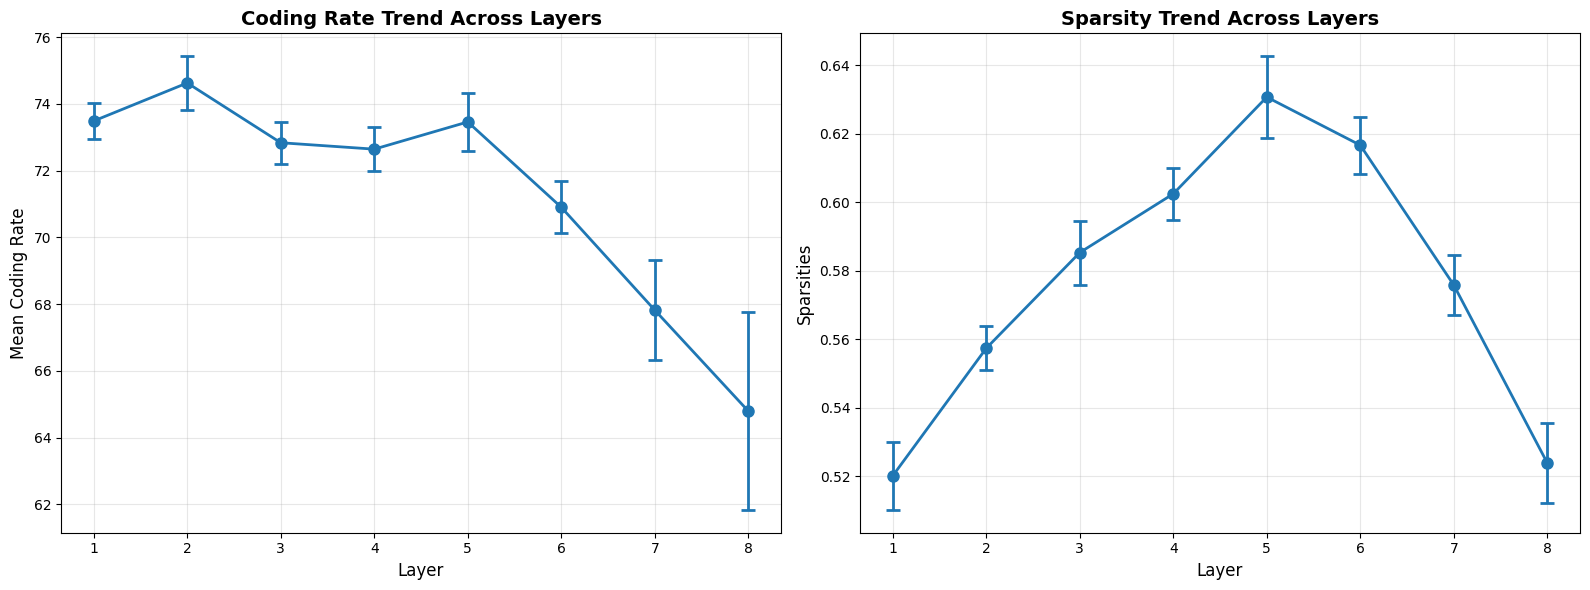

In [106]:
# Plot coding rate and sparsity trend across layers side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
layers = list(range(1, 9))  # 8 layers

# Coding Rate plot
axes[0].errorbar(
    layers, means, yerr=std_devs,
    marker='o', linestyle='-', linewidth=2, 
    markersize=8, capsize=5, capthick=2
)
axes[0].set_xlabel('Layer', fontsize=12)
axes[0].set_ylabel('Mean Coding Rate', fontsize=12)
axes[0].set_title('Coding Rate Trend Across Layers', fontsize=14, fontweight='bold')
axes[0].set_xticks(layers)
axes[0].grid(True, alpha=0.3)

# Sparsity plot
axes[1].errorbar(
    layers, sparsities, yerr=std_sparsities,
    marker='o', linestyle='-', linewidth=2, 
    markersize=8, capsize=5, capthick=2
)
axes[1].set_xlabel('Layer', fontsize=12)
axes[1].set_ylabel('Sparsities', fontsize=12)
axes[1].set_title('Sparsity Trend Across Layers', fontsize=14, fontweight='bold')
axes[1].set_xticks(layers)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

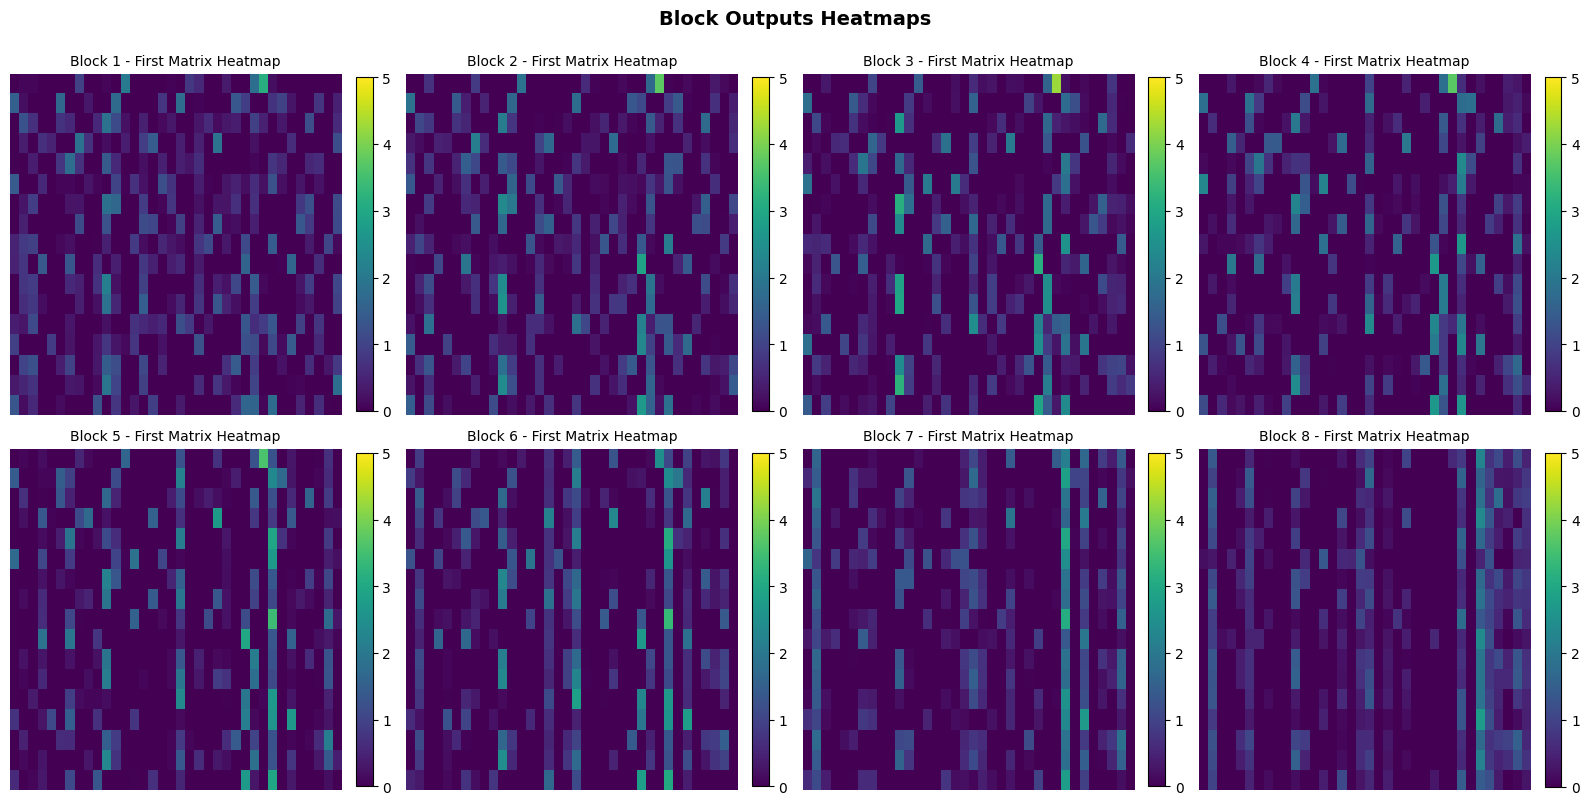

In [77]:
import matplotlib.pyplot as plt
import numpy as np

# Count how many blocks have data
num_blocks_with_data = sum(1 for block in block_outputs_list if len(block) > 0)

# Determine grid dimensions (2 rows, 4 columns for 8 blocks)
n_rows = 2
n_cols = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 8))
axes = axes.flatten()  # Flatten to 1D array for easier indexing

vmin, vmax = 0, 5
block_idx = 0

for i, block in enumerate(block_outputs_list):
    if len(block) > 0:
        matrix = block[0]  # Take the first matrix for this block
        ax = axes[block_idx]
        
        im = ax.imshow(matrix, cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax)
        ax.set_title(f'Block {i+1} - First Matrix Heatmap', fontsize=10)
        ax.axis('off')
        
        # Add colorbar to each subplot
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        
        block_idx += 1

# Hide unused subplots if any
for idx in range(block_idx, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Block Outputs Heatmaps', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

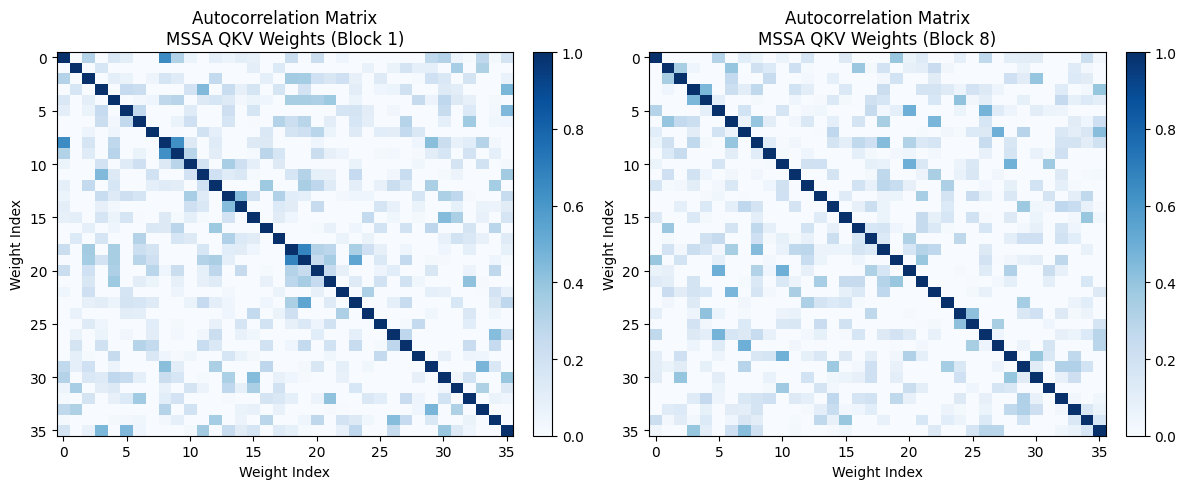

In [78]:
# # subspaces of the first and last layer side by side
import torch

# Prepare the weights for block 1 and block 8
qkv_weights_1 = model.crate.blocks[0].mssa.qkv.weight.data.cpu().numpy()
qkv_weights_8 = model.crate.blocks[-1].mssa.qkv.weight.data.cpu().numpy()

# Compute autocorrelation for both
autocorr_matrix_1 = np.corrcoef(qkv_weights_1)
autocorr_matrix_8 = np.corrcoef(qkv_weights_8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

vmin, vmax = 0, 1
im1 = axes[0].imshow(autocorr_matrix_1, cmap='Blues', aspect='auto', vmin=vmin, vmax=vmax)
axes[0].set_title("Autocorrelation Matrix\nMSSA QKV Weights (Block 1)")
axes[0].set_xlabel("Weight Index")
axes[0].set_ylabel("Weight Index")
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

im2 = axes[1].imshow(autocorr_matrix_8, cmap='Blues', aspect='auto', vmin=vmin, vmax=vmax)
axes[1].set_title("Autocorrelation Matrix\nMSSA QKV Weights (Block 8)")
axes[1].set_xlabel("Weight Index")
axes[1].set_ylabel("Weight Index")
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


# Self attention map for each prediction

w_list is a list of blocks, we only care about the last block and its attention map

In [101]:
# Extract CLS token and multiply with all other patches
# w_list[-1] has shape (b, n, (h d)) where:
#   b = batch size
#   n = number of patches (including CLS token at index 0)
#   h = number of heads
#   d = embedding dimension

# Get the last block's patch embeddings
# This is self.qkv(x) in the MSSA module   

# Get the last block's patch embeddings
last_block_embeddings = w_list[-1]  # Shape: (b, n, d)
print(f"Original last block embeddings shape: {last_block_embeddings.shape}")

# Rearrange to separate heads: (b, n, d) -> (b, h, n, d_head)
# where d = h * d_head (e.g., 128 = 8 * 16)
last_block_embeddings = rearrange(last_block_embeddings, 'b n (h d) -> b h n d', h=6)  # Shape: (b, h, n, d)
print(f"Rearranged last block embeddings shape: {last_block_embeddings.shape}")

# Extract CLS token (first patch) for each image in the batch and each head
emb_cls = last_block_embeddings[:, :, 0, :]  # Shape: (b, h, d)
print(f"CLS token shape: {emb_cls.shape}")

# Extract all other patches (excluding CLS token) for each head
other_patches = last_block_embeddings[:, :, 1:, :]  # Shape: (b, h, n-1, d)
print(f"Other patches shape: {other_patches.shape}")

# Multiply CLS token with all other patches for each head
# For each batch and head: compute dot product between CLS token and each patch
# (b, h, 1, d) @ (b, h, d, n-1) -> (b, h, 1, n-1) -> squeeze -> (b, h, n-1)
cls_similarities = torch.matmul(
    emb_cls.unsqueeze(2),  # Shape: (b, h, 1, d)
    other_patches.transpose(-1, -2)  # Shape: (b, h, d, n-1)
).squeeze(2)  # Shape: (b, h, n-1)
print(f"CLS similarities (dot product) shape: {cls_similarities.shape}")

# Apply softmax to normalize similarities across patches for each head
# Softmax over the patch dimension (dim=2) for each batch and head independently
cls_attention_weights = F.softmax(cls_similarities, dim=-1)  # Shape: (b, h, n-1)
print(f"CLS attention weights (softmax) shape: {cls_attention_weights.shape}")
print(f"CLS attention weights sum per batch and head (should be ~1.0):")
print(cls_attention_weights.sum(dim=2))  # Shape: (b, h) - should be all ~1.0

# Reshape attention weights and upsample to original image size
# cls_attention_weights shape: (batch_size=5, num_heads=8, num_patches=49)
# Reshape to (batch_size, num_heads, 7, 7) since 49 = 7*7 (patch grid)
batch_size, num_heads, num_patches = cls_attention_weights.shape #(10, 8, 49)
patch_grid_size = int(np.sqrt(num_patches))  # Should be 7 for 7x7 grid

# Reshape attention weights from (b, h, 49) to (b, h, 7, 7)
attention_2d = cls_attention_weights.view(batch_size, num_heads, patch_grid_size, patch_grid_size)

# Upsample from 7x7 to 28x28 (scale factor of 4)
# Use bilinear interpolation for smoother heatmaps
attention_upsampled = F.interpolate(
    attention_2d, # (b, h, 7, 7)
    size=(28, 28), 
    mode='bilinear', 
    align_corners=False
)  # Shape: (batch_size, num_heads, 28, 28)

print(f"Original attention weights shape: {cls_attention_weights.shape}")
print(f"Reshaped to 2D: {attention_2d.shape}")
print(f"Upsampled to image size: {attention_upsampled.shape}")

# Denormalize images for visualization (Fashion-MNIST normalization: mean=0.2860, std=0.3530)
mean = torch.tensor([0.2860])
std = torch.tensor([0.3530])
images_denorm_viz = images.cpu() * std.view(1, 1, 1, 1) + mean.view(1, 1, 1, 1)
images_denorm_viz = torch.clamp(images_denorm_viz, 0, 1)

# Convert to numpy for visualization
attention_upsampled_np = attention_upsampled.cpu().numpy()
images_denorm_np = images_denorm_viz.squeeze(1).numpy()  # Remove channel dimension: (batch_size, 28, 28)

# # Get predictions for the current batch
# with torch.no_grad():
#     outputs_viz = model(images)
#     predicted_labels_viz = outputs_viz.argmax(dim=1).cpu()
#     true_labels_viz = true_labels.cpu()



Original last block embeddings shape: torch.Size([10, 17, 36])
Rearranged last block embeddings shape: torch.Size([10, 6, 17, 6])
CLS token shape: torch.Size([10, 6, 6])
Other patches shape: torch.Size([10, 6, 16, 6])
CLS similarities (dot product) shape: torch.Size([10, 6, 16])
CLS attention weights (softmax) shape: torch.Size([10, 6, 16])
CLS attention weights sum per batch and head (should be ~1.0):
tensor([[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]])
Original atte

Visualizing 10 images with 6 attention heads


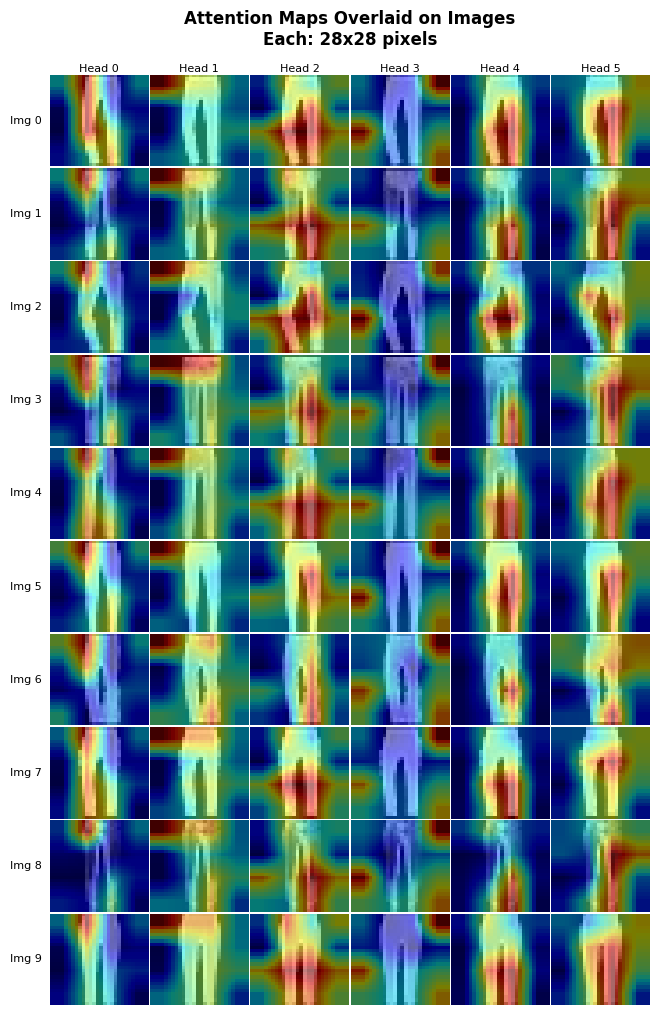

In [80]:
# Visualize attention maps overlaid on images in a grid
# Get actual number of heads from model
num_heads_viz = model.crate.blocks[0].mssa.heads
num_images = attention_upsampled_np.shape[0]
print(f"Visualizing {num_images} images with {num_heads_viz} attention heads")

# Grid: num_images rows (one per image) × num_heads columns (one per attention head)
# Each subplot will display a 28x28 image (1 pixel = 1 display pixel if dpi set accordingly)
fig, axes = plt.subplots(num_images, num_heads_viz, figsize=(num_heads_viz, num_images), dpi=100)

# Ensure axes is 2D array for consistent indexing
if num_images == 1:
    axes = np.expand_dims(axes, axis=0)
if num_heads_viz == 1:
    axes = np.expand_dims(axes, axis=1)

for i in range(num_images):
    for j in range(num_heads_viz):
        ax = axes[i, j]

        # Display base grayscale image
        ax.imshow(images_denorm_np[i], cmap='gray', aspect='auto', interpolation='nearest', vmin=0, vmax=1)
        
        # Overlay attention map as a colored heatmap, 28x28
        attention_map = attention_upsampled_np[i, j]
        attention_normalized = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min() + 1e-8)
        ax.imshow(attention_normalized, cmap='jet', alpha=0.5, aspect='auto', interpolation='nearest', vmin=0, vmax=1)
        
        # Remove axes/ticks for a tight 28x28 visualization
        ax.set_xticks([])
        ax.set_yticks([])
        ax.axis('off')
        
        # Add head labels to top row
        if i == 0:
            ax.set_title(f'Head {j}', fontsize=8, pad=2)
        # Add image index to leftmost column
        if j == 0:
            ax.text(-0.08, 0.5, f'Img {i}', transform=ax.transAxes, 
                   fontsize=8, ha='right', va='center', rotation=0)

plt.subplots_adjust(wspace=0.02, hspace=0.02, left=0, right=1, top=0.93, bottom=0)
plt.suptitle('Attention Maps Overlaid on Images\nEach: 28x28 pixels', 
             fontsize=12, fontweight='bold', y=0.995)
plt.show()


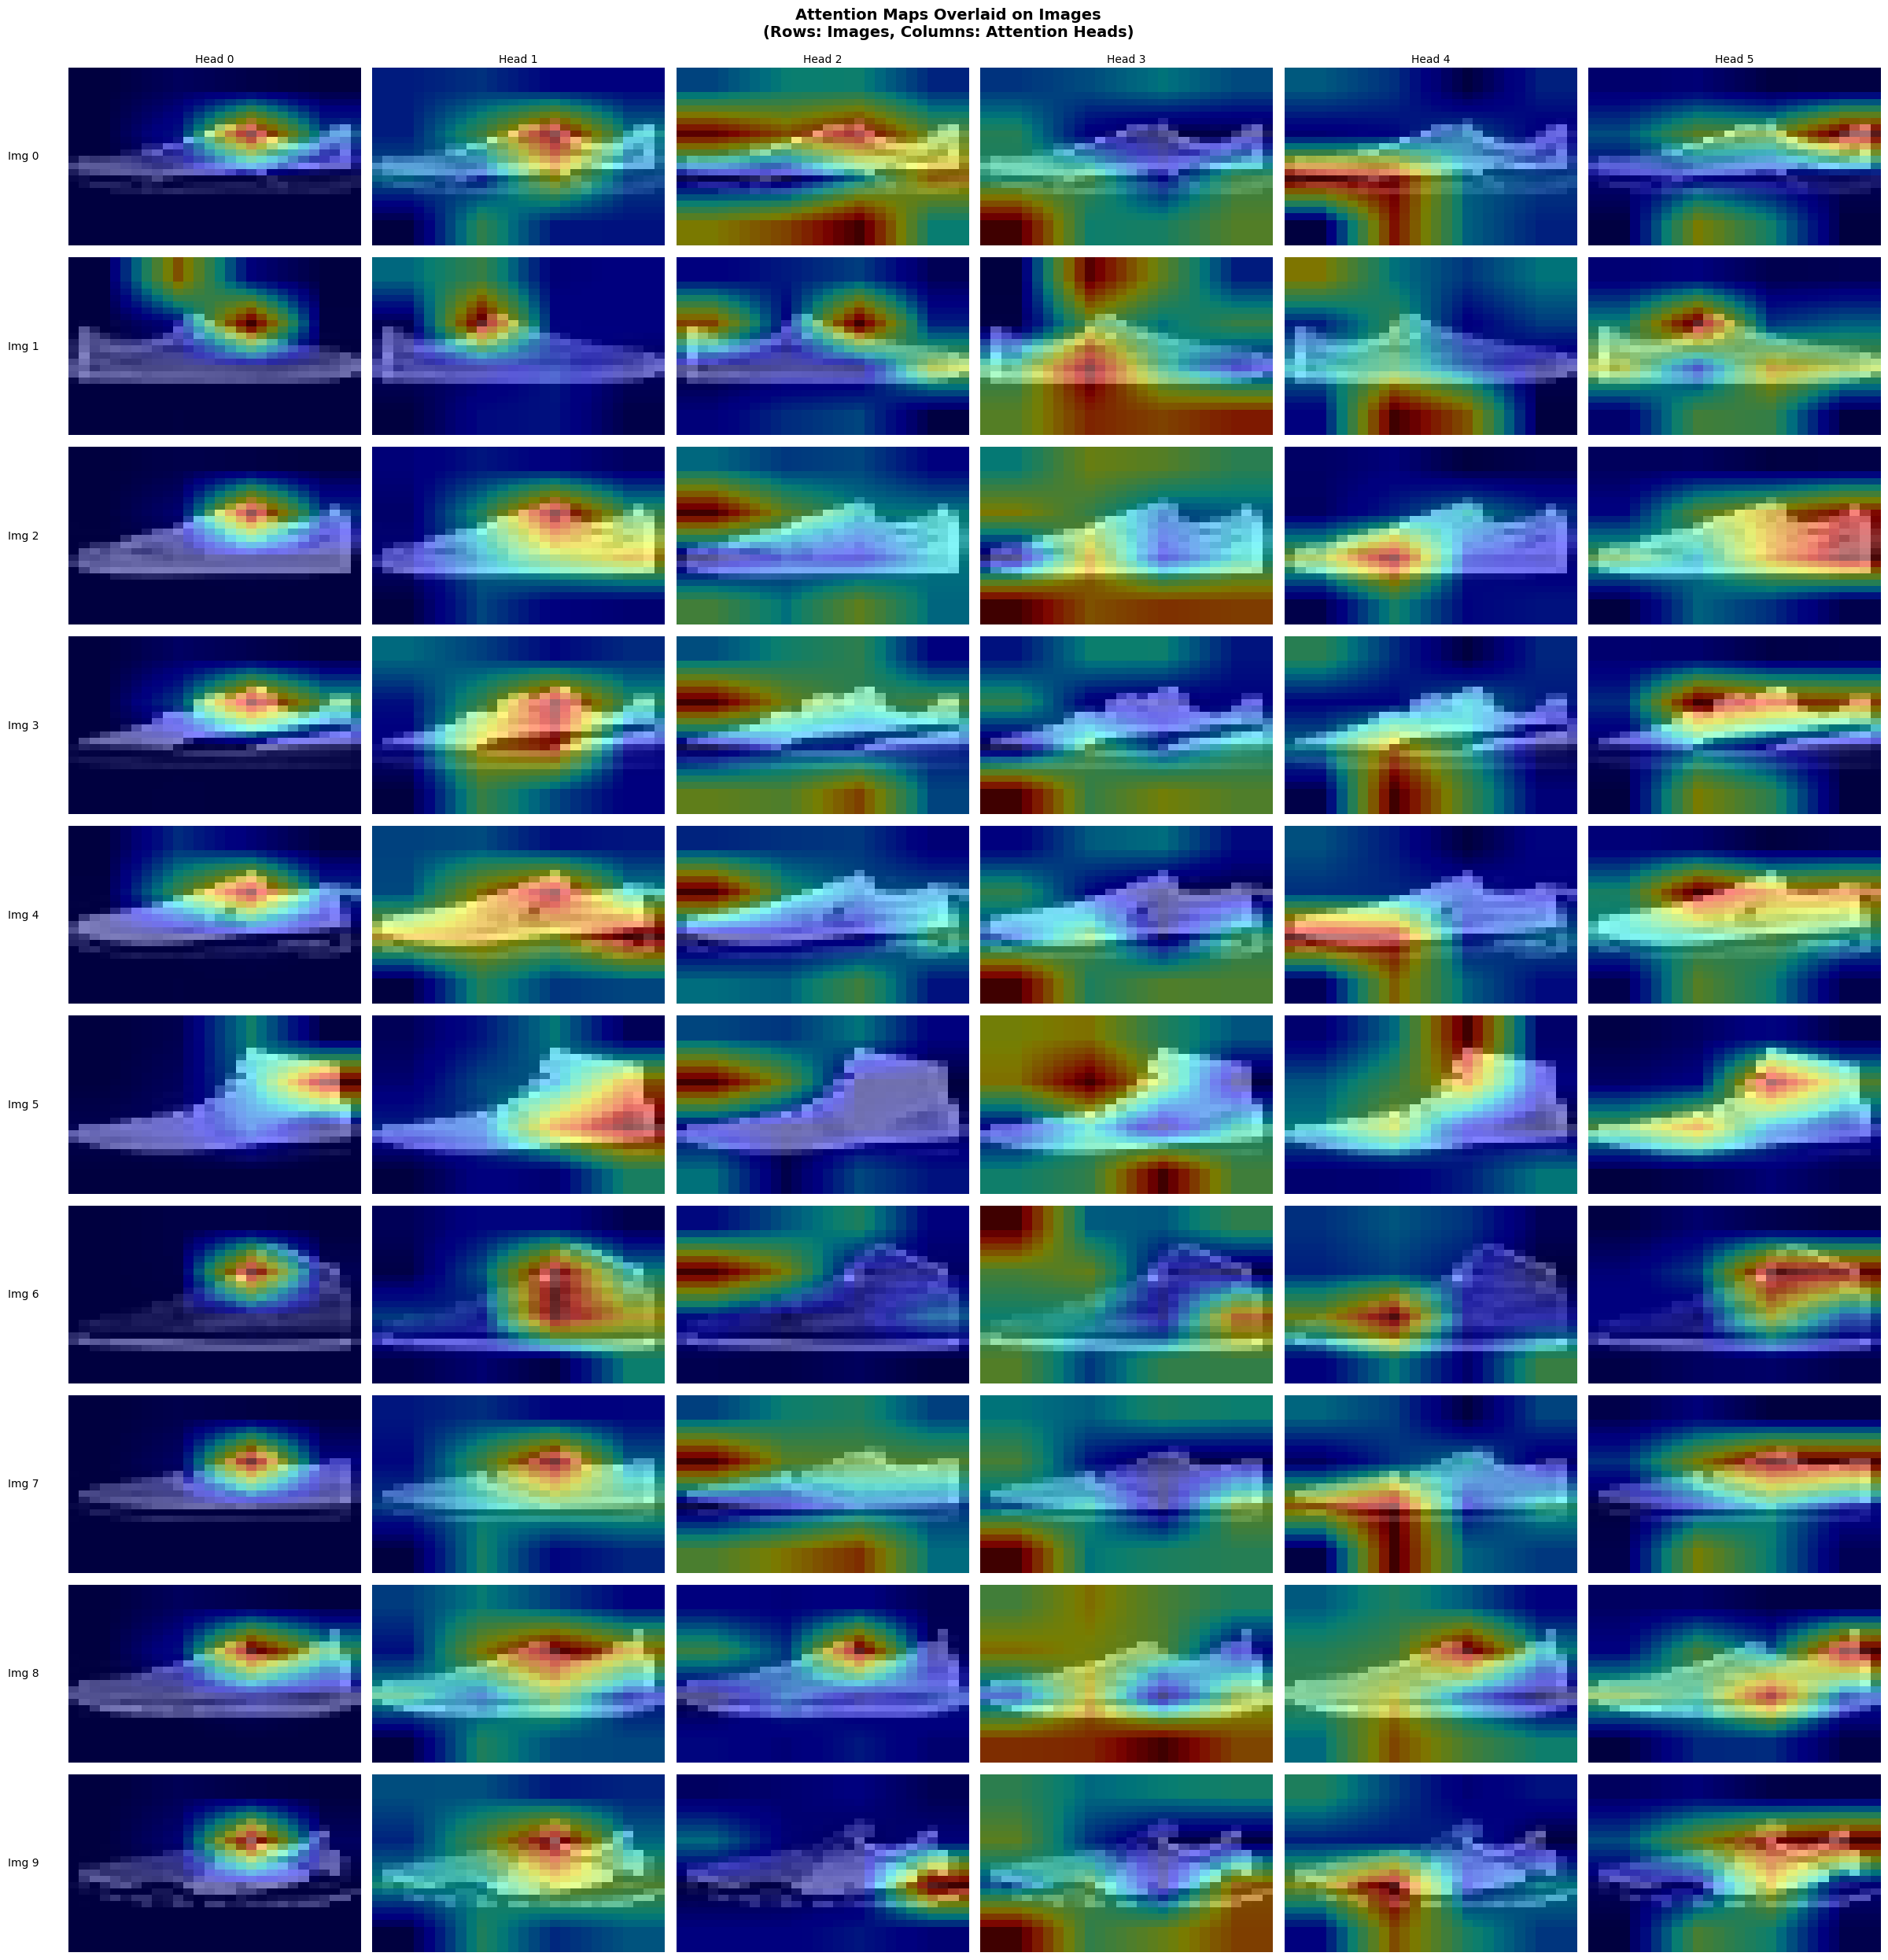

In [86]:
# Visualize attention maps overlaid on images in a grid
# Get actual number of heads from model
num_heads_viz = model.crate.blocks[0].mssa.heads
num_images = attention_upsampled_np.shape[0]

# Grid: num_images rows (one per image) × num_heads columns (one per attention head)
# Create figure with num_images rows and num_heads columns
fig, axes = plt.subplots(num_images, num_heads_viz, figsize=(4*num_heads_viz, 2.5*num_images))

# Iterate through each image (row) and each attention head (column)
for i in range(num_images):  # images
    for j in range(num_heads_viz):  # attention heads
        ax = axes[i, j]
        
        # Display the base grayscale image
        ax.imshow(images_denorm_np[i], cmap='gray', aspect='auto')
        
        # Overlay the attention map as a colored heatmap with transparency
        # Normalize attention map to [0, 1] for better visualization
        attention_map = attention_upsampled_np[i, j]
        attention_normalized = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min() + 1e-8)
        
        # Overlay attention map with jet colormap and alpha blending
        im = ax.imshow(attention_normalized, cmap='jet', alpha=0.5, aspect='auto')
        
        # Remove axes for cleaner visualization
        ax.axis('off')
        
        # Add column labels (attention head numbers) on top row
        if i == 0:
            ax.set_title(f'Head {j}', fontsize=10, pad=5)
        
        # Add row labels (image indices) on leftmost column
        if j == 0:
            ax.text(-0.1, 0.5, f'Img {i}', transform=ax.transAxes, 
                   fontsize=10, ha='right', va='center', rotation=0)

plt.suptitle('Attention Maps Overlaid on Images\n(Rows: Images, Columns: Attention Heads)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


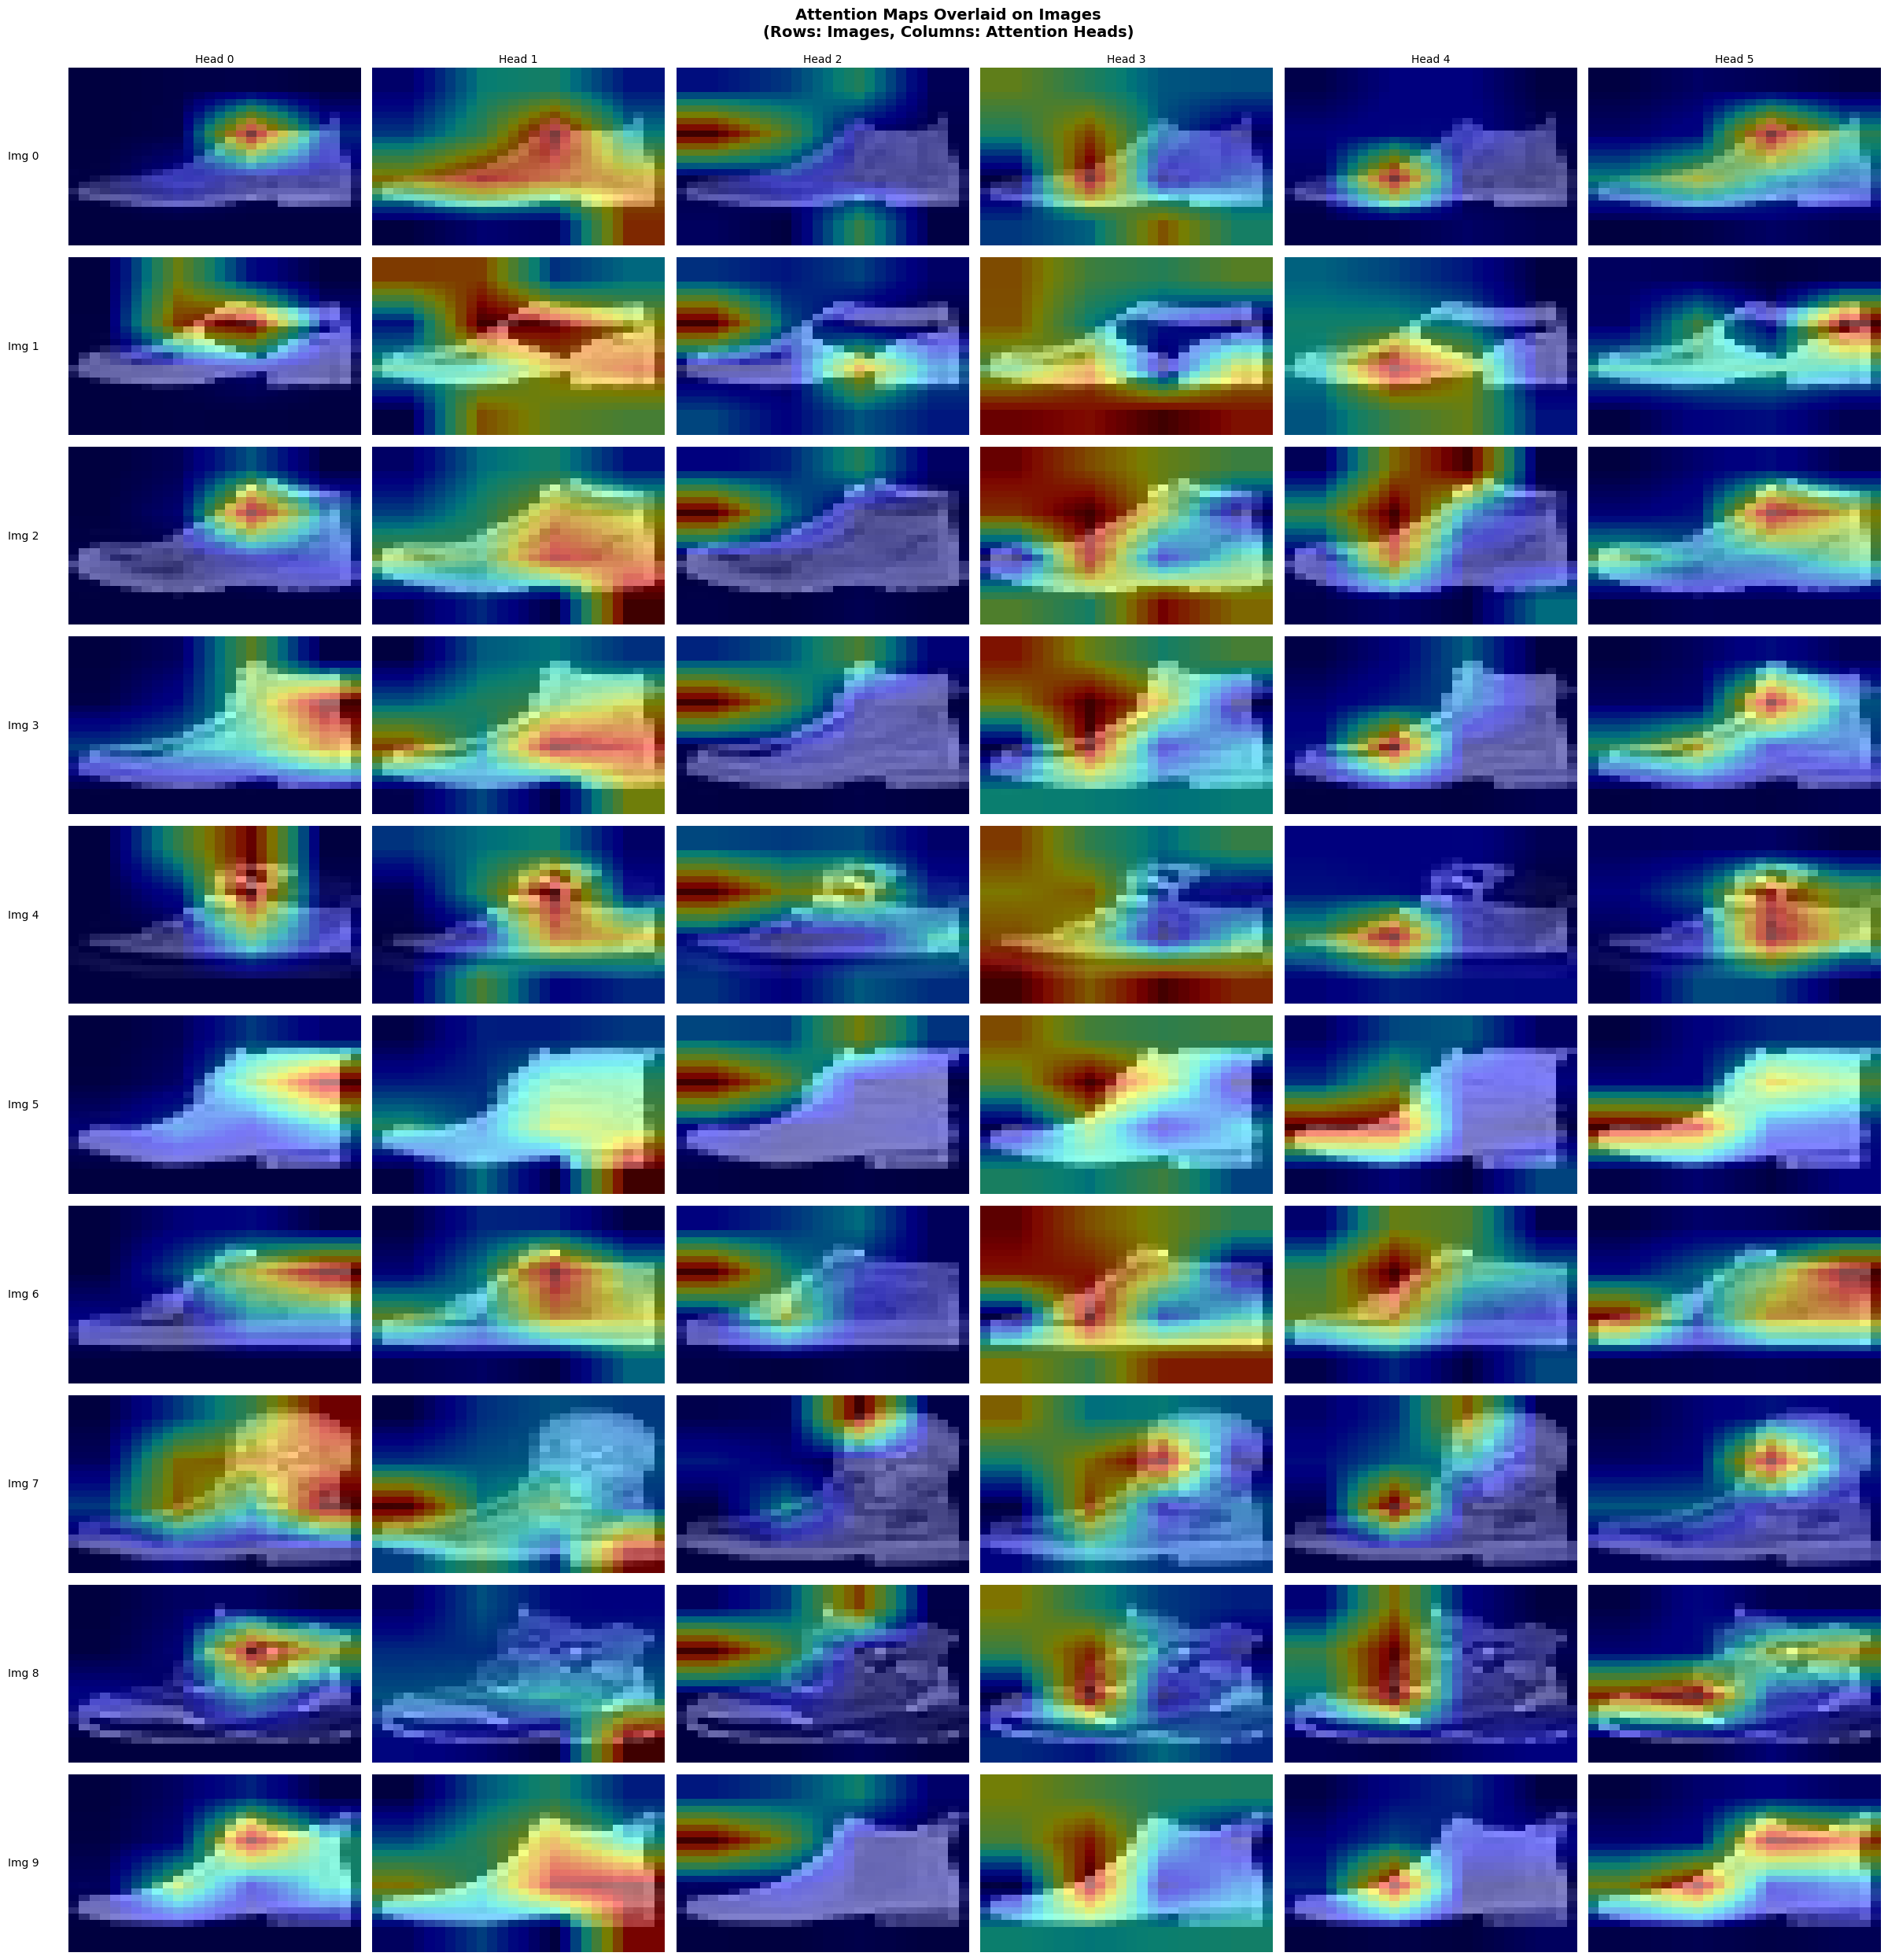

In [92]:
# Visualize attention maps overlaid on images in a grid
# Get actual number of heads from model
num_heads_viz = model.crate.blocks[0].mssa.heads
num_images = attention_upsampled_np.shape[0]

# Grid: num_images rows (one per image) × num_heads columns (one per attention head)
# Create figure with num_images rows and num_heads columns
fig, axes = plt.subplots(num_images, num_heads_viz, figsize=(4*num_heads_viz, 2.5*num_images))

# Iterate through each image (row) and each attention head (column)
for i in range(num_images):  # images
    for j in range(num_heads_viz):  # attention heads
        ax = axes[i, j]
        
        # Display the base grayscale image
        ax.imshow(images_denorm_np[i], cmap='gray', aspect='auto')
        
        # Overlay the attention map as a colored heatmap with transparency
        # Normalize attention map to [0, 1] for better visualization
        attention_map = attention_upsampled_np[i, j]
        attention_normalized = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min() + 1e-8)
        
        # Overlay attention map with jet colormap and alpha blending
        im = ax.imshow(attention_normalized, cmap='jet', alpha=0.5, aspect='auto')
        
        # Remove axes for cleaner visualization
        ax.axis('off')
        
        # Add column labels (attention head numbers) on top row
        if i == 0:
            ax.set_title(f'Head {j}', fontsize=10, pad=5)
        
        # Add row labels (image indices) on leftmost column
        if j == 0:
            ax.text(-0.1, 0.5, f'Img {i}', transform=ax.transAxes, 
                   fontsize=10, ha='right', va='center', rotation=0)

plt.suptitle('Attention Maps Overlaid on Images\n(Rows: Images, Columns: Attention Heads)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


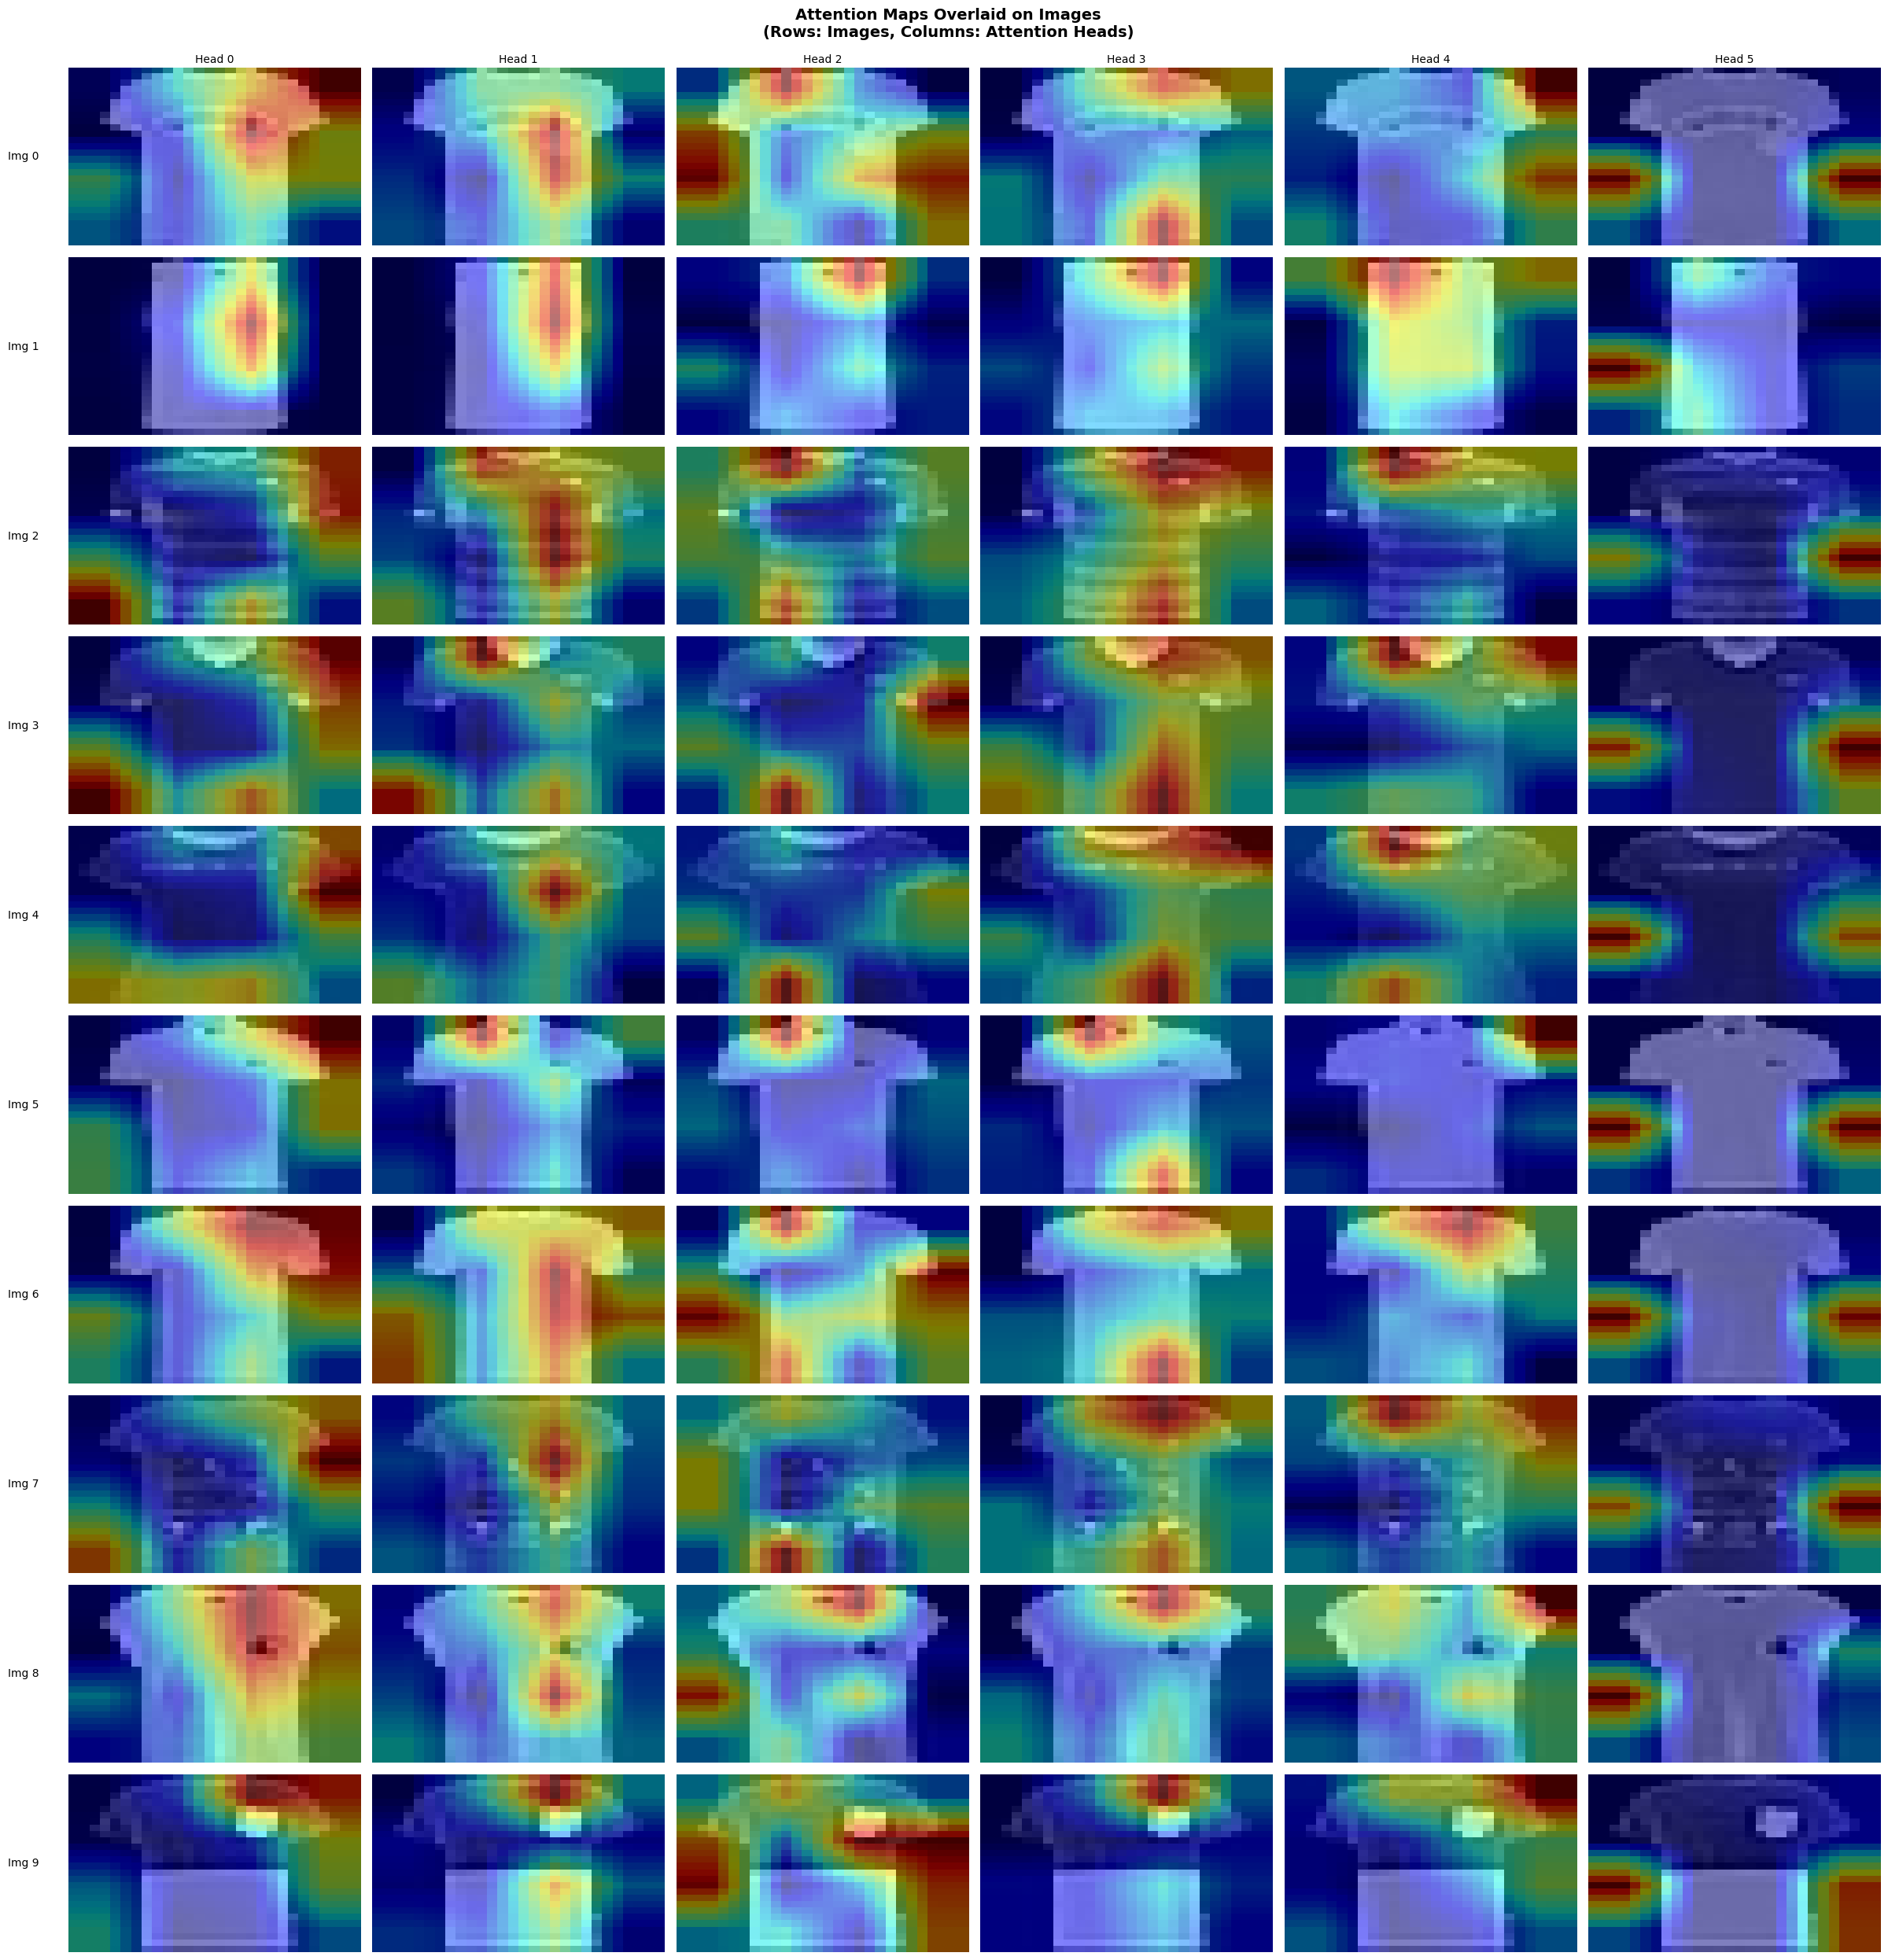

In [102]:
# Visualize attention maps overlaid on images in a grid
# Get actual number of heads from model
num_heads_viz = model.crate.blocks[0].mssa.heads
num_images = attention_upsampled_np.shape[0]

# Grid: num_images rows (one per image) × num_heads columns (one per attention head)
# Create figure with num_images rows and num_heads columns
fig, axes = plt.subplots(num_images, num_heads_viz, figsize=(4*num_heads_viz, 2.5*num_images))

# Iterate through each image (row) and each attention head (column)
for i in range(num_images):  # images
    for j in range(num_heads_viz):  # attention heads
        ax = axes[i, j]
        
        # Display the base grayscale image
        ax.imshow(images_denorm_np[i], cmap='gray', aspect='auto')
        
        # Overlay the attention map as a colored heatmap with transparency
        # Normalize attention map to [0, 1] for better visualization
        attention_map = attention_upsampled_np[i, j]
        attention_normalized = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min() + 1e-8)
        
        # Overlay attention map with jet colormap and alpha blending
        im = ax.imshow(attention_normalized, cmap='jet', alpha=0.5, aspect='auto')
        
        # Remove axes for cleaner visualization
        ax.axis('off')
        
        # Add column labels (attention head numbers) on top row
        if i == 0:
            ax.set_title(f'Head {j}', fontsize=10, pad=5)
        
        # Add row labels (image indices) on leftmost column
        if j == 0:
            ax.text(-0.1, 0.5, f'Img {i}', transform=ax.transAxes, 
                   fontsize=10, ha='right', va='center', rotation=0)

plt.suptitle('Attention Maps Overlaid on Images\n(Rows: Images, Columns: Attention Heads)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


In [ ]:
# Visualize attention maps overlaid on images in a grid
# Get actual number of heads from model
num_heads_viz = model.crate.blocks[0].mssa.heads
num_images = attention_upsampled_np.shape[0]

# Grid: num_images rows (one per image) × num_heads columns (one per attention head)
# Create figure with num_images rows and num_heads columns
fig, axes = plt.subplots(num_images, num_heads_viz, figsize=(4*num_heads_viz, 2.5*num_images))

# Iterate through each image (row) and each attention head (column)
for i in range(num_images):  # images
    for j in range(num_heads_viz):  # attention heads
        ax = axes[i, j]
        
        # Display the base grayscale image
        ax.imshow(images_denorm_np[i], cmap='gray', aspect='auto')
        
        # Overlay the attention map as a colored heatmap with transparency
        # Normalize attention map to [0, 1] for better visualization
        attention_map = attention_upsampled_np[i, j]
        attention_normalized = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min() + 1e-8)
        
        # Overlay attention map with jet colormap and alpha blending
        im = ax.imshow(attention_normalized, cmap='jet', alpha=0.5, aspect='auto')
        
        # Remove axes for cleaner visualization
        ax.axis('off')
        
        # Add column labels (attention head numbers) on top row
        if i == 0:
            ax.set_title(f'Head {j}', fontsize=10, pad=5)
        
        # Add row labels (image indices) on leftmost column
        if j == 0:
            ax.text(-0.1, 0.5, f'Img {i}', transform=ax.transAxes, 
                   fontsize=10, ha='right', va='center', rotation=0)

plt.suptitle('Attention Maps Overlaid on Images\n(Rows: Images, Columns: Attention Heads)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


In [ ]:
# Visualize attention maps overlaid on images in a grid
# Get actual number of heads from model
num_heads_viz = model.crate.blocks[0].mssa.heads
num_images = attention_upsampled_np.shape[0]

# Grid: num_images rows (one per image) × num_heads columns (one per attention head)
# Create figure with num_images rows and num_heads columns
fig, axes = plt.subplots(num_images, num_heads_viz, figsize=(4*num_heads_viz, 2.5*num_images))

# Iterate through each image (row) and each attention head (column)
for i in range(num_images):  # images
    for j in range(num_heads_viz):  # attention heads
        ax = axes[i, j]
        
        # Display the base grayscale image
        ax.imshow(images_denorm_np[i], cmap='gray', aspect='auto')
        
        # Overlay the attention map as a colored heatmap with transparency
        # Normalize attention map to [0, 1] for better visualization
        attention_map = attention_upsampled_np[i, j]
        attention_normalized = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min() + 1e-8)
        
        # Overlay attention map with jet colormap and alpha blending
        im = ax.imshow(attention_normalized, cmap='jet', alpha=0.5, aspect='auto')
        
        # Remove axes for cleaner visualization
        ax.axis('off')
        
        # Add column labels (attention head numbers) on top row
        if i == 0:
            ax.set_title(f'Head {j}', fontsize=10, pad=5)
        
        # Add row labels (image indices) on leftmost column
        if j == 0:
            ax.text(-0.1, 0.5, f'Img {i}', transform=ax.transAxes, 
                   fontsize=10, ha='right', va='center', rotation=0)

plt.suptitle('Attention Maps Overlaid on Images\n(Rows: Images, Columns: Attention Heads)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


In [ ]:
for i, block in enumerate(cls_attention_weights):
        matrix = block  # Take the first matrix for this block
        plt.figure(figsize=(6, 5))
        plt.imshow(matrix, cmap='viridis', aspect='auto')
        plt.colorbar()
        plt.title(f'Image {i+1} - First Matrix Heatmap')
        plt.show()

# PCA on Z space

# Latent diffusion

# Language model implementation

## Objectives

1. See if the same word apple belong to the same subspace in fruit and brand case